[![Open In Colab](./colab-badge.png)](https://colab.research.google.com/github/MooseNeuro/moose-notebooks/blob/main/Michaelis_menten_kinetics.ipynb) [![Binder](./binder_logo.png)](https://mybinder.org/v2/gh/MooseNeuro/moose-notebooks/HEAD?labpath=Michaelis_menten_kinetics.ipynb)

# MOOSE Overview

Upinder Bhalla(1) and Subhasis Ray(2)

(1) NCBS, TFR,Bangalore 
(2) CHINTA & IAI, TCG CREST, Kolkata

This notebook gives you a quick overview of MOOSE. To learn it, please take a look at the [README file](README.md) and follow the sequence according to your interests.

MOOSE is actively developed and maintained on github. To ask for help, or report issues, join the [discussion on github](https://github.com/orgs/MooseNeuro/discussions).

## Architecture of MOOSE
<img src="./media/images/moose_overview/moose_architecture_2.png" style="height:400px"> 

*Image credit: Upinder Bhalla*

The core code of MOOSE is written in C++ for speed. It is made available as a Python module via the `pymoose` package.

The classes provided by the `moose` module map to biological concepts like neuronal segments, ion channels, or components needed for simulation experiments, like a pulse generator, voltage clamp, differential amplifier, etc.

A model is built by connecting such components. During simulation, specialized numerical engines (solvers) compute the evolution of the model over time. 

## Use MOOSE as Python module

In [1]:
## Only required on colab! Uncomment to enable.
# !pip install pymoose --quiet

If you have pymoose installed, moose can be imported like this:

In [2]:
import moose

Check the installed version number

In [3]:
print(moose.__version__)

4.1.4


## Load a model from a file and simulate it

### Formats supported by MOOSE

MOOSE can read several common file formats for model description. Some of these are standard formats. Just like you can open a JPEG image with many different image processing software, a model file in a standard format can be loaded and simulate on any simulation platform that supports it.

MOOSE supports
1. SWC format for neuronal morphology description (extension `.swc`). Most [neuron tracing](https://en.wikipedia.org/wiki/Neuronal_tracing) tools like [ImageJ's SNT](https://imagej.net/plugins/snt/), [neutube](https://neutracing.com/), [Vaa3D](https://home.penglab.com/proj/vaa3d/home/index.html), can export 3D morphology traced from microscopy image stacks in this format. 
2. [GENESIS](http://www.genesis-sim.org/GENESIS/genesis.html) KKIT format for chemical kinetics is natively supported. You can find many published models in this format on the [DOQCS database](https://doqcs.ncbs.res.in/).
3. [SBML](https://sbml.org/) format is partially supported (chemical kinetics).
4. [NeuroML](https://neuroml.org/) format for neuronal model description is partially supported and is being further developed.

### `moose.loadModel` function can load a model description in any of these formats

MOOSE can load all these format with a single function: `loadModel`.

This repository contains some sample model files in the `model_files` subdirectory. We can load these (this may not work on colab or binder) using this form
```python
model_container = moose.loadModel('model-file-path', 'target-moose-element-path')
```

In [4]:
# Load a model in GENESIS kkit format
genesis = moose.loadModel('model_files/Kholodenko.g', '/genesis_model')

In [5]:
# check that /genesis_model has been created
moose.le('/')

Elements under /
    /Msgs
    /clock
    /classes
    /postmaster
    /genesis_model



In [6]:
# See the elements under the created model
moose.le(genesis)

Elements under /genesis_model[0]
    /genesis_model[0]/kinetics
    /genesis_model[0]/graphs
    /genesis_model[0]/moregraphs
    /genesis_model[0]/geometry
    /genesis_model[0]/groups
    /genesis_model[0]/info



### Running the simulation

You can simulate this model, by first initializing everything with `moose.reinit()` and then running the simulation with `moose.start(simulation_time)`.

In [7]:
moose.reinit()
moose.start(200)

In GENESIS KKIT models, data tables are located under `graphs` and `moregraphs` in the model tree.

In [8]:
moose.le(f'{genesis.path}/graphs')

Elements under /genesis_model[0]/graphs[0]
    /genesis_model[0]/graphs[0]/conc1
    /genesis_model[0]/graphs[0]/conc2



In [9]:
moose.le(f'{genesis.path}/graphs/conc1')

Elements under /genesis_model[0]/graphs[0]/conc1[0]
    /genesis_model[0]/graphs[0]/conc1[0]/Ras_MKKKK.Co
    /genesis_model[0]/graphs[0]/conc1[0]/MKKK_P.Co
    /genesis_model[0]/graphs[0]/conc1[0]/MKK_PP.Co
    /genesis_model[0]/graphs[0]/conc1[0]/MAPK_PP.Co



The names ending with `.Co` are tables recording concentrations.

### Plotting the data

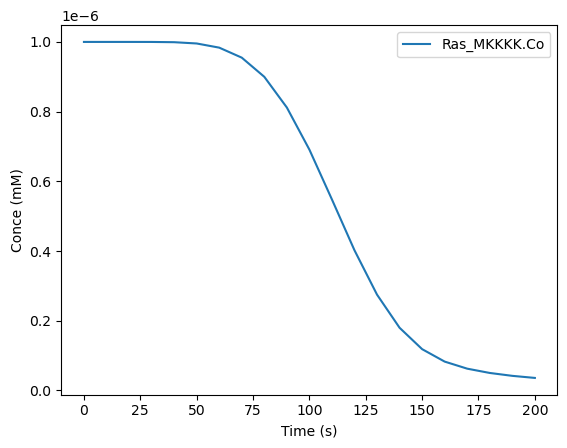

In [10]:
Ras_MKKK = moose.element(f'{genesis.path}/graphs[0]/conc1[0]/Ras_MKKKK.Co')
time = [ii * Ras_MKKK.dt  for ii in range(len(Ras_MKKK.vector))]   # create the time points corresponding to the data points

import pylab   # this is matplotlib interface for simple plotting
pylab.plot(time, Ras_MKKK.vector, label=Ras_MKKK.name)
pylab.xlabel('Time (s)')
pylab.ylabel('Conce (mM)')
pylab.legend()

## See module listing (list of functions, classes, constants etc)

You can use the Python builtin function `dir` to prints the classes, functions, and variables in the imported moose module.

In [11]:
dir(moose)

['ALLMSG',
 'AdExIF',
 'AdThreshIF',
 'Adaptor',
 'Annotator',
 'Arith',
 'BufPool',
 'CaConc',
 'CaConcBase',
 'Cell',
 'ChanBase',
 'ChemCompt',
 'Cinfo',
 'Clock',
 'Compartment',
 'CompartmentBase',
 'ConcChan',
 'CubeMesh',
 'CylMesh',
 'DiagonalMsg',
 'DifBuffer',
 'DifBufferBase',
 'DifShell',
 'DifShellBase',
 'DiffAmp',
 'Dsolve',
 'ElementField',
 'ElementFieldIterator',
 'EndoMesh',
 'Enz',
 'EnzBase',
 'Ex',
 'ExIF',
 'Example',
 'FaradayConst',
 'Finfo',
 'Function',
 'GapJunction',
 'GasConst',
 'GraupnerBrunel2012CaPlasticitySynHandler',
 'Group',
 'Gsolve',
 'HDF5DataWriter',
 'HDF5WriterBase',
 'HHChannel',
 'HHChannel2D',
 'HHChannelBase',
 'HHChannelF',
 'HHChannelF2D',
 'HHGate',
 'HHGate2D',
 'HHGateF',
 'HHGateF2D',
 'HSolve',
 'INMSG',
 'Id',
 'InputVariable',
 'IntFire',
 'IntFireBase',
 'Interpol',
 'Interpol2D',
 'IzhIF',
 'IzhikevichNrn',
 'Ksolve',
 'LIF',
 'Leakage',
 'LookupField',
 'MMPump',
 'MMenz',
 'MarkovChannel',
 'MarkovOdeSolver',
 'MarkovRateTabl

## MOOSE uses posix-style paths for objects

It mimicks directory traversal in Unix-like operating systems. All moose elements are organized like a directory tree. There are equivalents of standard shell commands for traversing and displaying them.

### Use `le` to **l**ist **e**lement

This is like `ls` in shell.


In [12]:
moose.le()    # similar to `ls` 

Elements under /
    /Msgs
    /clock
    /classes
    /postmaster
    /genesis_model



### Use `pwe` to show **p**resent **w**orking **e**lement

This is like like `pwd` in shell

In [13]:
moose.pwe()   # just like `pwd`

<moose.Shell path=/ id=0 dataIndex=0 fieldIndex=0>

Shell is the root element in MOOSE object hieararchy

like the filesystem root directory: `/`

### Use `ce` to **c**hange **e**lement

This is like `cd` in shell

In [14]:
moose.ce('/classes')  # just like cd

In [15]:
moose.pwe()

<moose.Neutral path=/classes[0] id=2 dataIndex=0 fieldIndex=0>

## More about essential MOOSE classes and functions
### `Neutral` is the base class for all MOOSE classes 

It is like `object` in Python. You can create a new element in moose by specifying a unique name or path to the class constructor. We use the terms `object` and `element` interchangeably for moose objects.


In [16]:
container = moose.Neutral('/my_container')

### Object paths

Every object has a `path` attribute that uniquely specifies its name and location in the elemnt tree.

In [17]:
print(container.path)

/my_container[0]


Just like creating filesystem directories with `mkdir` command, you can create a moose object with a valid path.

In [18]:
data = moose.Neutral('/my_container/data')

In [19]:
print(data)

<moose.Neutral path=/my_container[0]/data[0] id=564 dataIndex=0 fieldIndex=0>


### `ce` is flexible on argument type

You can `ce` using moose objects as well string paths.

In [20]:
moose.pwe()

<moose.Neutral path=/classes[0] id=2 dataIndex=0 fieldIndex=0>

In [21]:
moose.ce(data)

In [22]:
moose.pwe()

<moose.Neutral path=/my_container[0]/data[0] id=564 dataIndex=0 fieldIndex=0>

###  Every moose element is potentially an array (termed `vec` for vector in moose)

When you create an object with just the path, it creates a `vec` with a single element. When you print the path, the index of the element is included within brackets.


In [23]:
print(data.path)

/my_container[0]/data[0]


### Creating an array with multiple elements

You can create multi-element array objects by passing a positive integer for the `n` parameter to the constructor.

In [24]:
model = moose.Neutral(f'{container.path}/model', n=10)

In [25]:
print(model)

<moose.Neutral path=/my_container[0]/model[0] id=565 dataIndex=0 fieldIndex=0>


### Every object has a `numData` field for the number of elements within its `vec`

Every element in a `vec` shares the `numData` field.

In [26]:
print(model.numData)

10


### `vec` attribute for accessing the underlying array

Every element has the `vec` attribute that refers to the inderlying array. You can index the `vec` to access individual elements.

In [27]:
print(model.vec[1])

<moose.Neutral path=/my_container[0]/model[1] id=565 dataIndex=1 fieldIndex=0>


### `dataIndex` field is the index of the element

In [28]:
print(model.vec[2].dataIndex)

2


### The path includes the index of the element

In [29]:
print(model.path)

/my_container[0]/model[0]


In [30]:
print(model.vec[2].path)

/my_container[0]/model[2]


### Every element has an `id` identifying its `vec`

In [31]:
print(model.id)

<Id:  path=/my_container[0]/model id=565 class=Neutral>


### To get the path without index use `{element}.id.path`

In [32]:
print('model.path=', model.path)
print('model.id.path=', model.id.path)

model.path= /my_container[0]/model[0]
model.id.path= /my_container[0]/model


### Building paths with index

You can build paths by prepending the path of the `id` to the index. Python's `f-strings` are useful for this.

In [33]:
index = 1
path = f'{model.id.path}[{index}]/comp'
comp = moose.Compartment(path)

In [34]:
print(comp.path)

/my_container[0]/model[1]/comp[0]


You could also directly access the 2nd element under model by indexing its `vec` attribute to get the path.

In [35]:
comp2 = moose.Compartment(f'{model.vec[3].path}/comp2')
print(comp2.path)

/my_container[0]/model[3]/comp2[0]


### Referencing existing objects

Use the `moose.element(path)` function to get an existing object from a path string

In [36]:
same_comp = moose.element('/my_container[0]/model[1]/comp')

In [37]:
print('Before:', comp.Vm)

same_comp.Vm = 0.0    # set the Vm via reference to the existing comp

print('After:', comp.Vm)

Before: -0.06
After: 0.0


### Copying objects

Use `moose.copy(source_object, target_object)` to make a copy of an existing object. This is a deep copy.

In [38]:
copy_comp = moose.copy(comp, model.vec[7])
moose.le(model.vec[7])

Elements under /my_container[0]/model[7]
    /my_container[0]/model[7]/comp



In [39]:
print('Before: Original', comp.Vm, 'Copied', copy_comp.Vm)

copy_comp.Vm = 100.0

print('After: Original', comp.Vm, 'Copied', copy_comp.Vm)


Before: Original 0.0 Copied [0.]
After: Original 0.0 Copied [100.]


### Create copy with a different name

Like shell's `cp` command, you can specify a source, a target container, and new name in the arguments to `moose.copy()` to make a copy with a new name.

Its signature is:

`moose.copy(source_object, target_object, name=new_name)` 


In [40]:
copy_comp = moose.copy(comp, model.vec[7], 'mycomp')
moose.le(model.vec[7])

Elements under /my_container[0]/model[7]
    /my_container[0]/model[7]/comp
    /my_container[0]/model[7]/mycomp



### Setting attributes
The attributes available for each moose class are fixed. Unlike usual Python objects, assigning a new attribute is not allowed. The following throws an `AttributeError` exception.

In [42]:
a = moose.Compartment('c')
a.X = 10

AttributeError: setFieldGeneric::X is not found on path '/my_container[0]/data[0]/c[0]'.

## Getting help

### Python's builtin `help`
Regular python-builtin `help` command can show the documentation included in moose. This gives a lot of information, including inherited attributes.

In [43]:
help(moose.Compartment)

Help on class Compartment in module moose:

class Compartment(melement)
 |  Compartment(x, n=1, **kwargs)
 |
 |  class Compartment
 |
 |  Compartment object, for branching neuron models.
 |
 |  Author:   Upi Bhalla
 |
 |  Attributes:
 |  ===========
 |
 |  Value Attributes:
 |  -----------------
 |  Cm (type: double, class: Compartment)
 |    Membrane capacitance
 |
 |  Em (type: double, class: Compartment)
 |    Resting membrane potential
 |
 |  Im (type: double, class: Compartment)
 |    Current going through membrane
 |
 |  Ra (type: double, class: Compartment)
 |    Axial resistance of compartment
 |
 |  Rm (type: double, class: Compartment)
 |    Membrane resistance
 |
 |  Vm (type: double, class: Compartment)
 |    membrane potential
 |
 |  children (type: vector<Id>, class: Compartment)
 |    vector of ObjIds listing all children of current object
 |
 |  className (type: string, class: Compartment)
 |    Class Name of object
 |
 |  coords (type: vector<double>, class: Compartmen

### Use `moose.doc(topic)` for selecting information

You can use `moose.doc('Compartment')` to get help similar to python's `help` builtin. Moreover, you can get information about specific fields of a class.


In [44]:
# moose.doc('Compartment')  # commented out to avoid flood of informatoin
moose.doc('Compartment.Ra')

Ra: double - ValueFinfo
Axial resistance of compartmentQuery: Ra


## Different types of fields

MOOSE objects have several different kinds of fields that behave differently. These are
1. `value` fields for storing values (numeric, string, or vectors of simple datatypes)
2. `lookup` fields for map/dictionary like lookup
3. `element` fields for fields that are elements themselves
4. `src` fields for connecting objects, this is like an outlet
5. `dest` fields for connecting objects, this is like an inlet
6. `shared` fields for connecting objects, this is like a combination of one or more inlets and outlets

In [45]:
print('* Value fields')
print(moose.getFieldNames('Table', 'value'))

* Value fields
['children', 'className', 'columnName', 'datafile', 'destFields', 'dt', 'fieldIndex', 'format', 'idValue', 'index', 'me', 'msgIn', 'msgOut', 'name', 'numData', 'numField', 'outfile', 'outputValue', 'parent', 'path', 'plotDump', 'size', 'sourceFields', 'this', 'threshold', 'tick', 'useSpikeMode', 'useStreamer', 'valueFields', 'vector']


In [46]:
print('* Lookup fields')
print(moose.getFieldNames('Table', 'lookup'))
print('* Element fields')
print(moose.getFieldNames('Table', 'element'))

* Lookup fields
['isA', 'msgDestFunctions', 'msgDests', 'neighbors', 'y']
* Element fields
[]


You can also query the field names with the name of the class and field type.

In [47]:
print('* Source fields')
print(moose.getFieldNames('Table', 'src'))

* Source fields
['childOut', 'requestOut']


In [48]:
print('* Dest fields')
moose.getFieldNames('Table', 'dest')

* Dest fields


['clearVec',
 'compareVec',
 'compareXplot',
 'getChildren',
 'getClassName',
 'getColumnName',
 'getDatafile',
 'getDestFields',
 'getDt',
 'getFieldIndex',
 'getFormat',
 'getIdValue',
 'getIndex',
 'getIsA',
 'getMe',
 'getMsgDestFunctions',
 'getMsgDests',
 'getMsgIn',
 'getMsgOut',
 'getName',
 'getNeighbors',
 'getNumData',
 'getNumField',
 'getOutfile',
 'getOutputValue',
 'getParent',
 'getPath',
 'getPlotDump',
 'getSize',
 'getSourceFields',
 'getThis',
 'getThreshold',
 'getTick',
 'getUseSpikeMode',
 'getUseStreamer',
 'getValueFields',
 'getVector',
 'getY',
 'input',
 'linearTransform',
 'loadCSV',
 'loadXplot',
 'loadXplotRange',
 'notifyAddMsgDest',
 'notifyAddMsgSrc',
 'notifyCopy',
 'notifyCreate',
 'notifyDestroy',
 'notifyMove',
 'parentMsg',
 'plainPlot',
 'process',
 'reinit',
 'setColumnName',
 'setDatafile',
 'setFormat',
 'setName',
 'setNumData',
 'setNumField',
 'setOutfile',
 'setPlotDump',
 'setThis',
 'setThreshold',
 'setTick',
 'setUseSpikeMode',
 'setUs

## Connecting objects: `source` and `dest` fields

In moose all components talk to each other through messages. 

To pass these messages you need to set up connections before you start a simulation. This is like setting up a pipeline or wiring.

<img src="./media/images/moose_overview/messages.png" style="height:400px"> 


In addition to `moose.getFieldNames`, source and destination fields are accessible via the `sourceFields` and `destFields` on each element.

In [49]:
moose.ce(model)
comp = moose.Compartment('compartment')
tab = moose.Table('tab')
print('Dest fields on comp:', comp.destFields)
print('Source fields on tab:', tab.sourceFields)

Dest fields on comp: ['parentMsg', 'setThis', 'getThis', 'setName', 'getName', 'getMe', 'getParent', 'getChildren', 'getPath', 'getClassName', 'setNumData', 'getNumData', 'setNumField', 'getNumField', 'getIdValue', 'getIndex', 'getFieldIndex', 'setTick', 'getTick', 'getDt', 'getValueFields', 'getSourceFields', 'getDestFields', 'getMsgOut', 'getMsgIn', 'getNeighbors', 'getMsgDests', 'getMsgDestFunctions', 'getIsA', 'notifyCreate', 'notifyCopy', 'notifyDestroy', 'notifyMove', 'notifyAddMsgSrc', 'notifyAddMsgDest', 'setVm', 'getVm', 'setCm', 'getCm', 'setEm', 'getEm', 'getIm', 'setInject', 'getInject', 'setInitVm', 'getInitVm', 'setRm', 'getRm', 'setRa', 'getRa', 'setDiameter', 'getDiameter', 'setLength', 'getLength', 'setX0', 'getX0', 'setY0', 'getY0', 'setZ0', 'getZ0', 'setX', 'getX', 'setY', 'getY', 'setZ', 'getZ', 'setCoords', 'getCoords', 'injectMsg', 'randInject', 'injectMsg', 'cable', 'displace', 'setGeomAndElec', 'process', 'reinit', 'initProc', 'initReinit', 'handleChannel', 'han

### Connecting a table to retrieve a compartment's voltage

The `Table` class has a source field called `requestOut` to send request for numeric data, and every class in MOOSE has a `get{Value}` destination field to return the value of the value field `value`. Thus, the membrane potential `Vm` of a `Compartment` can be retrieved within a simulation from the `getVm` dest field.

In [50]:
moose.connect(tab, 'requestOut', comp, 'getVm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[5] id=5 dataIndex=5 fieldIndex=0>

### You can check the existing connections on an object with `moose.showmsg`

The output has the format:

```
INCOMING:
 {path}, [dest field] <-- {path of source element}, [src field]
 ...
 
OUTGOING:
  {path}, [src field] --> {path of target element}, [dest field]

```  

In [51]:
moose.showmsg(tab)

INCOMING:
  /my_container[0]/model[0]/tab[0] [parentMsg] <-- /my_container[0]/model[0] [childOut]
  /my_container[0]/model[0]/tab[0] [process,reinit] <-- /clock[0] [process8,reinit8]

OUTGOING:
  /my_container[0]/model[0]/tab[0] [requestOut] --> /my_container[0]/model[0]/compartment[0] [getVm]



The output is telling that the element `mytable[0]` has: 
1. An incoming connection into `parentMsg` field from `childOut` field of `data[0]`. The tree structure of moose elements is created via these parent-child relationship.
2. Another (composite) incoming connection into the shared field combining `process` and `reinit` destinations from the shared field combining `process8` and `reinit8` src fields on `clock[0]`. This is how the global clock controls execution of simulation on each element.
3. An outgoing connection from `requestOut` src field to the `getVm` dest field of `compartment[0]`.

## Initializing and running the simulation
After creating or loading a model, you must initialize the system with

`moose.reinit()`

and then start the simulation with 

`moose.start(runtime)`

If we do this now, initially the `vector` field of the `tab` will be empty (*Note: `vector` is the array of values stored in the `Table`, do not confuse this with `vec`, which refers to the vector of elements*).


In [52]:
print('Before simulation', tab.vector)

Before simulation []


In [53]:
moose.reinit()
moose.start(1.0)

During simulation, at each timestep, the `Table` requests the value of `Vm` from the `Compartment` via the `requestOut -> getVm` connection. The retrieved value is appended to the `vector` field of the `Table`. All this happens within the single function call `moose.start()`.

In [54]:
print('After simulation', tab.vector)

After simulation [-0.06 -0.06 -0.06 ... -0.06 -0.06 -0.06]


### The simulation timestep
Each object has a `dt` field indicating the size of the timestep for its simulation

In [55]:
print('Compartment dt', comp.dt)
print('Table dt', tab.dt)

Compartment dt 5e-05
Table dt 0.0001


## Advanced exploration of the element tree: pattern matching with wildcards

For large models, finding the elements by path becomes hard. The `wildcardFind` function in moose lets you search them by pattern matching. It also allows recursive search, i.e., looking into the children, grand children, great grand children, etc. This is similar to [globbing](https://en.wikipedia.org/wiki/Glob_(programming)) in Unix shells.

The wildcard character is `'#'`. A single `'#'` matches a single level in the element tree.

In [56]:
found = moose.wildcardFind('/#')
for obj in found: 
    print(obj.path)

/clock[0]
/classes[0]
/postmaster[0]
/Msgs[0]
/genesis_model[0]
/my_container[0]


You can use this to get a list of elements under a given path. Below we retrieve all the children of `/my_container`.

In [57]:
found = moose.wildcardFind('/my_container/#')
for obj in found: 
    print(obj.path)

/my_container[0]/data[0]
/my_container[0]/model[0]
/my_container[0]/model[1]
/my_container[0]/model[2]
/my_container[0]/model[3]
/my_container[0]/model[4]
/my_container[0]/model[5]
/my_container[0]/model[6]
/my_container[0]/model[7]
/my_container[0]/model[8]
/my_container[0]/model[9]


### Recursive search with `'##'`

Use the wildcard `##` in the argument to `wildcardFind` in order to search recursively through all the levels below a given path.

In [58]:
found = moose.wildcardFind('/my_container/##')
for obj in found: 
    print(obj.path)

/my_container[0]/data[0]
/my_container[0]/model[0]
/my_container[0]/model[1]
/my_container[0]/model[2]
/my_container[0]/model[3]
/my_container[0]/model[4]
/my_container[0]/model[5]
/my_container[0]/model[6]
/my_container[0]/model[7]
/my_container[0]/model[8]
/my_container[0]/model[9]
/my_container[0]/model[1]/comp[0]
/my_container[0]/model[3]/comp2[0]
/my_container[0]/model[7]/comp[0]
/my_container[0]/model[7]/mycomp[0]
/my_container[0]/data[0]/c[0]
/my_container[0]/model[0]/compartment[0]
/my_container[0]/model[0]/tab[0]


### Search by condition
You can also include conditions in wildcard search. The syntax of the argument is `{wildcard}[{KEY}{condition}{value}]`

For example, `'/my_container/##[TYPE=Compartment]'` matches all `Compartment` objects under `my_container` at any level.
Alternative syntax for this is: 

In [59]:
found = moose.wildcardFind('/my_container/##[TYPE=Compartment]')
for obj in found: 
    print('path=', obj.path, 'Vm=', obj.Vm)

path= /my_container[0]/model[1]/comp[0] Vm= -0.06
path= /my_container[0]/model[3]/comp2[0] Vm= -0.06
path= /my_container[0]/model[7]/comp[0] Vm= -0.06
path= /my_container[0]/model[7]/mycomp[0] Vm= -0.06
path= /my_container[0]/data[0]/c[0] Vm= -0.06
path= /my_container[0]/model[0]/compartment[0] Vm= -0.06


You can also use condition on field values. For example, you can retrieve all objects whose `Vm` value is negative with the string `'/my_container/##[FIELD(Vm)<0]'`. *Note that there must be no space in the expression.*

In [60]:
found = moose.wildcardFind('/my_container/##[FIELD(Vm)<0]')
for obj in found: 
    print('path=', obj.path, 'Vm=', obj.Vm)

path= /my_container[0]/model[1]/comp[0] Vm= -0.06
path= /my_container[0]/model[3]/comp2[0] Vm= -0.06
path= /my_container[0]/model[7]/comp[0] Vm= -0.06
path= /my_container[0]/model[7]/mycomp[0] Vm= -0.06
path= /my_container[0]/data[0]/c[0] Vm= -0.06
path= /my_container[0]/model[0]/compartment[0] Vm= -0.06
0: Error: SetGet::strGet: Field Vm not found on Element data
0: Error: SetGet::strGet: Field Vm not found on Element tab
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGet::strGet: Field Vm not found on Element model
0: Error: SetGe

## Deleting objects
MOOSE objects persist until explicitly deleted. Referencing deleted object can crash Python.

In [61]:
print('Present working element path:')
moose.pwe()
print('\nListing of elements under this path:')
moose.le()
if moose.exists('compartment'):
    moose.delete('compartment')
print('Listing of elements under this path after "delete":')
moose.le()

Present working element path:

Listing of elements under this path:
Elements under /my_container[0]/model[0]
    /my_container[0]/model[0]/compartment
    /my_container[0]/model[0]/tab

Listing of elements under this path after "delete":
Elements under /my_container[0]/model[0]
    /my_container[0]/model[0]/tab

